# Safety Scoring - Crime Dataset Processing

### MUST HAVE SPD_CRIME_DATA_2008-PRESENT.CSV

In [ ]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import gaussian_kde

# Coordinates for downtown Seattle area
north = 47.62425802431359
south = 47.596252480947555
east  = -122.31765250756945
west  = -122.35919327219091

north, south, east, west = 47.60171959708996, 47.595863783720105, -122.31146573381761, -122.32242746142184

# load file
crime_df = pd.read_csv(r"REPLACE WITH YOUE PATH TO SPD_CRIME_DATA")

# drop rows with missing coords
crime_df = crime_df.dropna(subset=['Latitude', 'Longitude'])
crime_df['Latitude'] = pd.to_numeric(crime_df['Latitude'], errors='coerce')
crime_df['Longitude'] = pd.to_numeric(crime_df['Longitude'], errors='coerce')

# drop irrelevant rows
crime_df = crime_df.drop(columns=['Report Number','Report DateTime','Block Address', 'Offense Category','Shooting Type Group', 'NIBRS Group AB', "NIBRS Crime Against Category", "Beat", 'Precinct', 'Sector', 'Neighborhood', 'Reporting Area', 'NIBRS Offense Code Description', 'NIBRS_offense_code'])

# convert Offense DateTime col to datetime format
crime_df['Offense DateTime'] = pd.to_datetime(crime_df['Offense Date'])

# only consider the incidents that are within defined bounds
crime_past_year = crime_df[
    (crime_df['Latitude'] <= north) &
    (crime_df['Latitude'] >= south) &
    (crime_df['Longitude'] <= east) &
    (crime_df['Longitude'] >= west)
].copy()

C:\Users\desmo\AppData\Local\Temp\ipykernel_40384\1586651344.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crime_df['Offense DateTime'] = pd.to_datetime(crime_df['Offense Date'])


### ✦ Current Dataset Filtering/Changes Overview (implemented below):
1. all crime incidents are from the past year only
2. exclude crimes with irrelevant crime categories
3. separated crimes by day and night
4. changed "Offense Sub Category" into "Offense Type"
5. changed offense type names to be simpler and more concise


### ✦ Crime Type Name Simplification

In [3]:
simplified_names = {
    'TRESPASS': 'Trespass',
    'EXTORTION/FRAUD/FORGERY/BRIBERY (INCLUDES BAD CHECKS)': 'Fraud/Bribery',
    'MOTOR VEHICLE THEFT': 'Motor Vehicle Theft',
    'LARCENY-THEFT': 'Larceny',
    'BURGLARY': 'Burglary',
    'PROPERTY OFFENSES (INCLUDES STOLEN, DESTRUCTION)': 'Property Offenses',
    'DUI': 'DUI',
    'WEAPON LAW VIOLATION': 'Weapon Law Violation',
    'LIQUOR LAW VIOLATIONS & DRUNKENNESS': 'Liquor Violations',
    'PROSTITUTION OFFENSES': 'Prostitution',
    'NARCOTIC VIOLATIONS (INCLUDES DRUG EQUIP.)': 'Narcotics',
    'DISORDERLY CONDUCT & VAGRANCY VIOLATIONS': 'Disorderly Conduct',
    'ARSON': 'Arson',
    'ROBBERY': 'Robbery',
    'ASSAULT OFFENSES': 'Assault',
    'KIDNAPPING/ABDUCTION': 'Kidnapping',
    'SEX OFFENSES': 'Sex Offenses',
    'AGGRAVATED ASSAULT': 'Aggravated Assault',
    'RAPE': 'Rape',
    'HUMAN TRAFFICKING': 'Human Trafficking',
    'HOMICIDE': 'Homicide',
}

print(crime_past_year.info())
crime_past_year['Offense Type'] = crime_past_year['Offense Sub Category'].replace(simplified_names)

crime_past_year = crime_past_year.drop(columns='Offense Sub Category')


# Check for any rows where Offense Type is Homicide
has_homicide = (crime_past_year['Offense Type'] == "Homicide").any()

if has_homicide:
    homicide_count = (crime_past_year['Offense Type'] == "Homicide").sum()
    print(f"Yes, there are {homicide_count} Homicide offenses in the past year.")
else:
    print("No Homicide offenses found in the past year.")

<class 'pandas.core.frame.DataFrame'>
Index: 17605 entries, 86 to 1468703
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Offense ID            17605 non-null  int64         
 1   Offense Date          17605 non-null  object        
 2   Offense Sub Category  17605 non-null  object        
 3   Latitude              17605 non-null  float64       
 4   Longitude             17605 non-null  float64       
 5   Offense DateTime      17605 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 962.8+ KB
None
No Homicide offenses found in the past year.


### ✦ Assigning Crime Scores

In [4]:
crime_scores = {
    'Trespass': 1,
    'Fraud/Bribery': 2,
    'Motor Vehicle Theft': 3,
    'Larceny': 4,
    'Burglary': 4,
    'Property Offenses': 4,
    'DUI': 5,
    'Weapon Law Violation': 5,
    'Liquor Violations': 5,
    'Prostitution': 5,
    'Narcotics': 6,
    'Disorderly Conduct': 6,
    'Arson': 7,
    'Robbery': 8,
    'Assault': 8,
    'Kidnapping': 9,
    'Sex Offenses': 9,
    'Aggravated Assault': 10,
    'Rape': 10,
    'Human Trafficking': 10,
    'Homicide': 10,
}


crime_past_year.loc[:, 'Crime Score'] = crime_past_year['Offense Type'].map(crime_scores)



In [5]:
# looking at unmapped categories
unmapped = crime_past_year[crime_past_year['Crime Score'].isna()]
print("Unmapped crime categories:")
print(unmapped['Offense Type'].unique())
crime_past_year = crime_past_year.dropna(subset=['Crime Score'])
print("Remaining categories:")
unique_types = sorted(crime_past_year['Offense Type'].unique().tolist())

if "Homicide" not in unique_types:
    unique_types.append("Homicide")

print("Final list of offense categories:")
print(unique_types)



Unmapped crime categories:
['ALL OTHER' '999' 'ANIMAL CRUELTY' 'UNKNOWN' 'PORNOGRAPHY'
 'VIOLATION OF NO CONTACT ORDER' 'GAMBLING OFFENSES'
 'NON-VIOLENT FAMILY OFFENSES']
Remaining categories:
Final list of offense categories:
['Aggravated Assault', 'Arson', 'Assault', 'Burglary', 'DUI', 'Disorderly Conduct', 'Fraud/Bribery', 'Kidnapping', 'Larceny', 'Motor Vehicle Theft', 'Narcotics', 'Property Offenses', 'Robbery', 'Sex Offenses', 'Trespass', 'Weapon Law Violation', 'Homicide']


### ✦ Getting crimes from past year only

In [6]:
# define one year ago
one_yr_ago = datetime.today() - timedelta(days=365)

# get crimes in past year
crime_past_year = crime_past_year[crime_past_year["Offense DateTime"] >= one_yr_ago]
print(crime_past_year.info())

# check
print(crime_past_year['Offense DateTime'].min())
print(crime_past_year['Offense DateTime'].max())

<class 'pandas.core.frame.DataFrame'>
Index: 1101 entries, 1066 to 1468442
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Offense ID        1101 non-null   int64         
 1   Offense Date      1101 non-null   object        
 2   Latitude          1101 non-null   float64       
 3   Longitude         1101 non-null   float64       
 4   Offense DateTime  1101 non-null   datetime64[ns]
 5   Offense Type      1101 non-null   object        
 6   Crime Score       1101 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 68.8+ KB
None
2024-08-04 20:36:00
2025-08-03 12:34:00


### ✦ Splitting day/night
- split_day_night function: takes in dataframe, day start, and day end in military time (0-24), returns two dataframes
- day start and day end default to 6 am and 6 pm

In [7]:
# function to split
# dataframe, date col name, daytime start (inclusive) and daytime end (exclusive)
# returns two dataframes for day/night, crime_day and crime_night
def split_day_night(df, date_col='Offense DateTime', day_start=6, day_end=18):
    
    # get hour
    df = df.copy()
    df['Hour'] = df[date_col].dt.hour

    # daytime (within specified range)
    crime_day = df[(df['Hour'] >= day_start) & (df['Hour'] < day_end)].copy()

    # nighttime (outside range)
    crime_night = df[(df['Hour'] < day_start) | (df['Hour'] >= day_end)].copy()

    # remove hour col at end
    crime_day = crime_day.drop(columns=['Hour'])
    crime_night = crime_night.drop(columns=['Hour'])

    return crime_day, crime_night


### ✦ example call for above function:


#### calling with default daytime hours: 6 AM to 6 PM
crime_daytime, crime_nighttime = split_day_night(crime_past_year)

#### calling with custom daytime hours: 7 AM to 8 PM
custom_day, custom_night = split_day_night(crime_past_year, day_start=7, day_end=20)


## Day/Night Crime EDA

### ✦ Variables def

In [8]:
# split data using function
crime_daytime, crime_nighttime = split_day_night(crime_past_year)

# count the crimes by type
day_counts = crime_daytime['Offense Type'].value_counts().sort_index()
night_counts = crime_nighttime['Offense Type'].value_counts().sort_index()

# create a list of all crime types (some may only be during day or night)
all_crimes = sorted(set(day_counts.index).union(set(night_counts.index)))

# align counts (missing crimes = 0)
day_values = [day_counts.get(crime, 0) for crime in all_crimes]
night_values = [night_counts.get(crime, 0) for crime in all_crimes]


### ✦ Plotting Crime Type Count by Day/Night

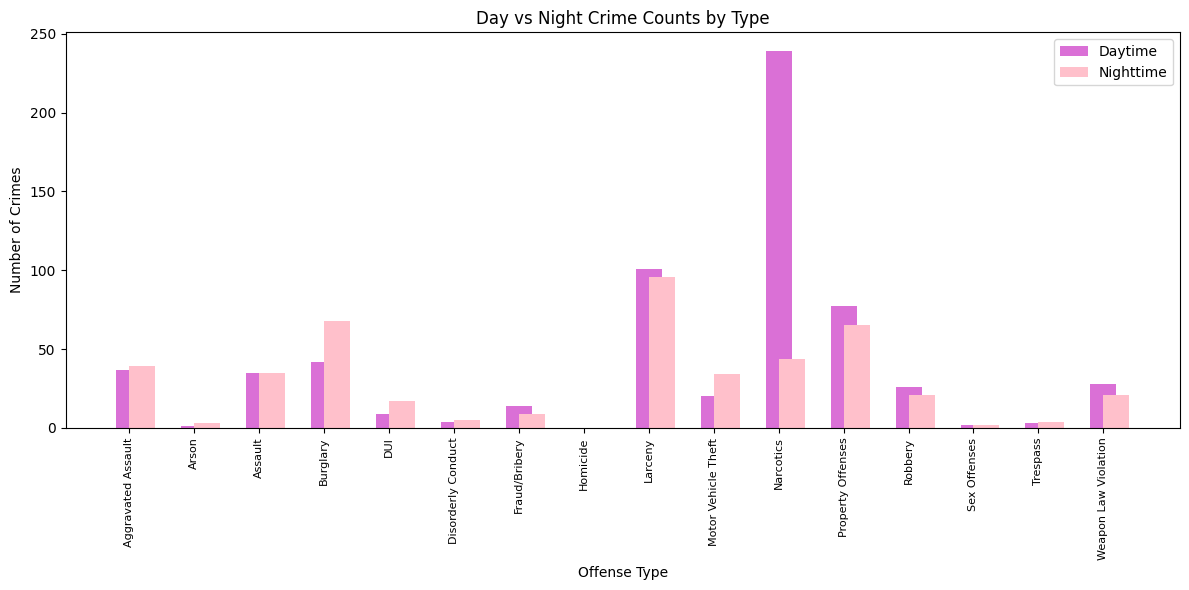

In [9]:
expected_crimes = sorted(set(day_counts.index) | set(night_counts.index) | {"Homicide"})

# Align day/night counts with this full list
day_values = [day_counts.get(crime, 0) for crime in expected_crimes]
night_values = [night_counts.get(crime, 0) for crime in expected_crimes]

# Plot
x = range(len(expected_crimes))
plt.figure(figsize=(12, 6))

plt.bar(x, day_values, width=0.4, label='Daytime', align='center', color='orchid')
plt.bar(x, night_values, width=0.4, label='Nighttime', align='edge', color='pink')

plt.xticks(x, expected_crimes, rotation=90, fontsize=8)
plt.xlabel('Offense Type')
plt.ylabel('Number of Crimes')
plt.title('Day vs Night Crime Counts by Type')
plt.legend()
plt.tight_layout()
plt.show()

### ✦ Scatter map of crimes by day and night

In [10]:

# Create a scatter mapbox of crimes

# Daytime map
fig_day = px.scatter_map(
    crime_daytime,
    lat="Latitude",
    lon="Longitude",
    hover_name="Offense Type",
    color="Crime Score",
    zoom=11,
    center={"lat": 47.61, "lon": -122.33},
    height=600,
    title="Daytime Crimes"
)
fig_day.update_layout(map_style="open-street-map")
fig_day.show()

# Nighttime map
fig_night = px.scatter_map(
    crime_nighttime,
    lat="Latitude",
    lon="Longitude",
    hover_name="Offense Type",
    color="Crime Score",
    zoom=11,
    center={"lat": 47.61, "lon": -122.33},
    height=600,
    title="Nighttime Crimes"
)
fig_night.update_layout(map_style="open-street-map")
fig_night.show()



### ✦ Ratios and Investigating if Crimes are Overrepresented/Underrepresented
1. plot shows whether a crime is more common during the day or at night
    - negative = happens more during the day
    - positive = happens more at night
2. print statements compare raw crime type counts and percentage of that crime type within its time window
    - Total crimes during night and total crimes during day might differ
    - Instead of counting raw numbers, look at proportion of that crime type to all crimes in that time window
    - For example, 3000 daytime larcenies vs. 30 Nighttime larcenies seems really bad for day, but what if total daytime    crimes is 50000, but total nighttime crimes is only 31?
        - Do any of these exist? (No)

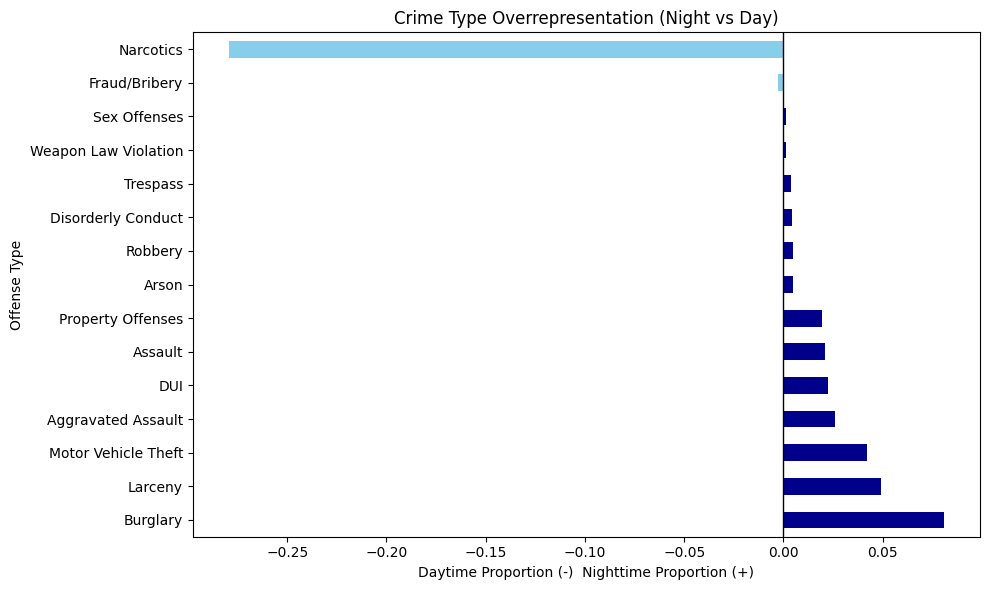

Crime Type: Narcotics
Total Narcotics at Night: 44
Total Narcotics in Day: 239
Percentage Narcotics at Night: 9.503239740820735
Percentage Narcotics in Day: 37.460815047021946
 
Crime Type: Larceny
Total Larceny at Night: 96
Total Larceny in Day: 101
Percentage Larceny at Night: 20.734341252699785
Percentage Larceny in Day: 15.830721003134796
 
Crime Type: Assault
Total Assault at Night: 35
Total Assault in Day: 35
Percentage Assault at Night: 7.559395248380129
Percentage Assault in Day: 5.4858934169279
 
Crime Type: Property Offenses
Total Property Offenses at Night: 65
Total Property Offenses in Day: 77
Percentage Property Offenses at Night: 14.038876889848812
Percentage Property Offenses in Day: 12.068965517241379
 
Crime Type: Burglary
Total Burglary at Night: 68
Total Burglary in Day: 42
Percentage Burglary at Night: 14.686825053995682
Percentage Burglary in Day: 6.583072100313479
 
Crime Type: Robbery
Total Robbery at Night: 21
Total Robbery in Day: 26
Percentage Robbery at Night

In [11]:
day_proportions = day_counts / day_counts.sum()
night_proportions = night_counts / night_counts.sum()

proportions_diff = (night_proportions - day_proportions).sort_values(ascending=False)

plt.figure(figsize=(10,6))
proportions_diff.plot(kind='barh', color=['darkblue' if v>0 else 'skyblue' for v in proportions_diff])
plt.axvline(0, color='black', linewidth=1)
plt.title("Crime Type Overrepresentation (Night vs Day)")
plt.xlabel("Daytime Proportion (-)  Nighttime Proportion (+)")
plt.ylabel("Offense Type")
plt.tight_layout()
plt.show()

crime_types_arr = crime_past_year['Offense Type'].unique()

i = 0
count = 0

for type in crime_types_arr:
    ex_type = type
    print(f'Crime Type: {ex_type}')

    total_night = night_counts.get(ex_type, 0)
    print(f'Total {ex_type} at Night: {total_night}')

    total_day = day_counts.get(ex_type, 0)
    print(f'Total {ex_type} in Day: {total_day}')

    night_total = night_counts.sum()
    night_pct = (night_counts.get(ex_type, 0) / night_total) * 100
    print(f'Percentage {ex_type} at Night: {night_pct}')

    day_total = day_counts.sum()
    day_pct = (day_counts.get(ex_type, 0) / day_total) * 100
    print(f'Percentage {ex_type} in Day: {day_pct}')
    print(' ')

    if(total_night > total_day) and (night_pct < day_pct):
        count += 1
    if(total_night < total_day) and (night_pct > day_pct):
        count += 1

print(f'Number of paradox flips: {count}')



### ✦ Severity

In [12]:
print("Average severity daytime:", crime_daytime['Crime Score'].mean())
print("Average severity nighttime:", crime_nighttime['Crime Score'].mean())


Average severity daytime: 5.481191222570533
Average severity nighttime: 5.185745140388769


### ✦ Crimes Separated by Day/Night and Grouped By Day of Week
- based on relative distribution, not raw counts
    -> higher bar on one weekday = more crimes on that weekday compared to other weekdays

In [13]:
# days list
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_by_weekday = day_by_weekday.reindex(weekday_order, fill_value=0)
night_by_weekday = night_by_weekday.reindex(weekday_order, fill_value=0)

# normalize/make it relative
day_prop = day_by_weekday / day_by_weekday.sum()
night_prop = night_by_weekday / night_by_weekday.sum()

# Plot side by side
plt.figure(figsize=(10, 6))
width = 0.4
x = range(len(weekday_order))

# day
plt.bar(
    [i - width/2 for i in x], 
    day_prop,
    width=width,
    color="skyblue",
    label="Daytime"
)

# night
plt.bar(
    [i + width/2 for i in x], 
    night_prop,
    width=width,
    color="darkblue",
    label="Nighttime"
)

plt.xticks(x, weekday_order, rotation=45)
plt.ylabel("Proportion of Crimes")
plt.title("Crime Distribution by Weekday (Day vs Night)")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'day_by_weekday' is not defined

### ✦ Hourly Crime Distribution

<Axes: title={'center': 'Crimes by Hour of Day'}, xlabel='hour'>

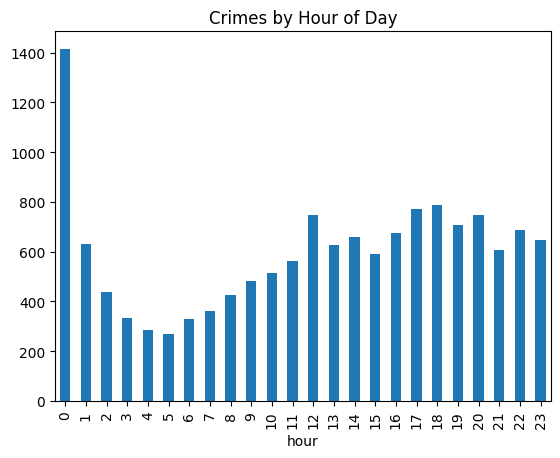

In [ ]:
crime_past_year['hour'] = crime_past_year['Offense DateTime'].dt.hour
crime_past_year.groupby('hour').size().plot(kind='bar', title='Crimes by Hour of Day')


In [ ]:
# export day/night separately to csv
# day
crime_daytime.to_csv('crime_daytime.csv', index=False)

# night
crime_nighttime.to_csv('crime_nighttime.csv', index=False)
